In [48]:
import igra
import matplotlib.pyplot as plt

In [2]:
stations = igra.download.stationlist('/tmp')

Download complete, reading table ...
Data read from: /tmp/igra2-station-list.txt
Data processed 2878


In [3]:
igra.download.station("USM00072469", "/tmp")

https://www1.ncdc.noaa.gov/pub/data/igra/data/data-por//USM00072469-data.txt.zip  to  /tmp/USM00072469-data.txt.zip
Downloaded:  /tmp/USM00072469-data.txt.zip


In [4]:
data, station = igra.read.igra("USM00072469", "/tmp/USM00072469-data.txt.zip")

In [5]:
data

<xarray.Dataset>
Dimensions:   (date: 59577, pres: 16)
Coordinates:
  * date      (date) datetime64[ns] 1948-10-16T03:00:00 ... 2022-07-09
  * pres      (pres) float64 1e+03 2e+03 3e+03 5e+03 ... 8.5e+04 9.25e+04 1e+05
Data variables:
    gph       (date, pres) float64 nan nan nan nan nan ... 3.231e+03 nan nan nan
    temp      (date, pres) float64 nan nan nan nan nan ... 288.8 nan nan nan
    rhumi     (date, pres) float64 nan nan nan nan nan ... nan nan nan nan nan
    dpd       (date, pres) float64 nan nan nan nan nan ... 1.3 12.0 nan nan nan
    windd     (date, pres) float64 nan nan nan nan nan ... 110.0 nan nan nan
    winds     (date, pres) float64 nan nan nan nan nan ... 9.8 7.7 nan nan nan
    flag_int  (date, pres) float64 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 1.0 1.0 1.0
Attributes:
    ident:         USM00072469
    source:        NOAA NCDC
    dataset:       IGRAv2
    processed:     UNIVIE, IMG
    interpolated:  to pres levs (#16)

In [39]:
list(data.coords)
data.rhumi.loc[dict(pres=7000)]
data2022 = data.rhumi.loc["2022-01-01":"2022-07-09"]
data2022

<xarray.DataArray 'rhumi' (date: 377, pres: 16)>
array([[0.004, 0.007, 0.008, ...,   nan,   nan,   nan],
       [0.002, 0.003, 0.004, ...,   nan,   nan,   nan],
       [0.003, 0.003, 0.003, ...,   nan,   nan,   nan],
       ...,
       [  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [  nan,   nan,   nan, ...,   nan,   nan,   nan],
       [  nan,   nan,   nan, ...,   nan,   nan,   nan]])
Coordinates:
  * date     (date) datetime64[ns] 2022-01-01 2022-01-01T12:00:00 ... 2022-07-09
  * pres     (pres) float64 1e+03 2e+03 3e+03 5e+03 ... 8.5e+04 9.25e+04 1e+05
Attributes:
    units:          1
    standard_name:  relative_humidity

In [46]:
RH20220101 = data2022.loc["2022-01-01T00:00:00.000000000"]

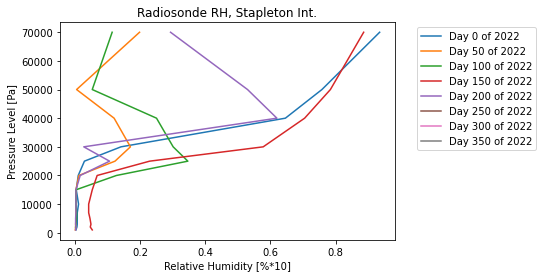

In [76]:
fig, ax = plt.subplots()

for i in range(0,len(data2022.date), 50):
    ax.plot(data2022[i], RH20220101.pres, label="Day " + str(i) + " of 2022")

ax.set_xlabel("Relative Humidity [%*10]")
ax.set_ylabel("Pressure Level [Pa]")
ax.set_title("Radiosonde RH, Stapleton Int.")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
